In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [4]:
iris = load_iris()
x = iris.data
data = pd.DataFrame(x, columns = iris.feature_names)
print(data)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]


Sice this is Unsupervised there is no output features, 3 flower species (which is not specified)

We want the model to discover the patterns on its own

In [6]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

* Scaling ensures all features have mean = 0 and variance = 1.

* Important for K-Means because it uses distance (Euclidean distance) to form clusters.

Determinning Optimal number of Clusters

In [9]:
inertia = []
for k in range(1,11):
    kmeans = KMeans(n_clusters =k, random_state = 42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

The abaove code meaning
* First Creating a emplty list named inertia to store all the values
* next is loop
* then choosing what is the number of clusters, so we are choosing from 1 to 10.
* then for each clusters from 1 t0 10 we are creating a KMeans model
* Then fitting the model for each values of k
* then finding the inerta(kmeans.inertia_ : the dist btw the data points and the centroid) for each clusters, and then appending into the above empty list(inertia = []).
* lower inertia --> better cluster

In [12]:
# printing the inertia values
for i, val in enumerate(inertia, start =1 ):
    print(f'Number of cluster = {i}, Inertia ={val:.2f}')

Number of cluster = 1, Inertia =600.00
Number of cluster = 2, Inertia =222.36
Number of cluster = 3, Inertia =191.02
Number of cluster = 4, Inertia =114.35
Number of cluster = 5, Inertia =91.05
Number of cluster = 6, Inertia =81.55
Number of cluster = 7, Inertia =80.78
Number of cluster = 8, Inertia =64.43
Number of cluster = 9, Inertia =55.71
Number of cluster = 10, Inertia =51.12


In the above code
* We are printing the inertia acquired for each clusters
* i --> cluster num, val --> inertia value
* if start =1 , is not there it strats from 0
* enumerate meaning:
* Suppose, inertia = [500.45, 300.21, 180.67, 150.32]

* enumerate() gives you two things:

* i → the position/cluster number
* val → the inertia value

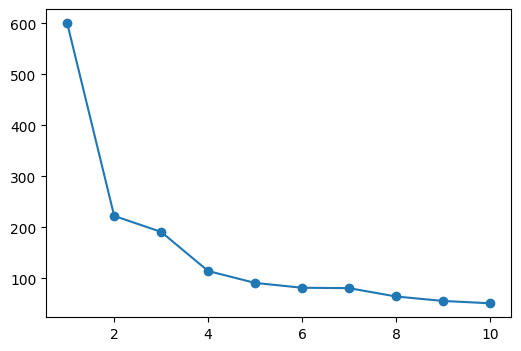

In [ ]:
#plot
plt.figure(figsize = (6,4))
plt.plot(range(1,11), inertia, marker = 'o') # inertia - this contains only the inertia values, range(1,11)- to show the cluster numbers
plt.title("Elbow Method to find optimal clusters")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

The sharp drop happens until k = 4.

After that, the curve flattens — meaning adding more clusters doesn’t reduce inertia much.

Therefore, the optimal number of clusters = 4.

In [ ]:
# applying k means clustering
kmeans1 = KMeans(n_clusters = 4, random_state = 42)
clusters = kmeans1.fit_predict(x_scaled)
#this can be done together liike this or seperately like kmeans1.fit(x_scales), clusters = k_means1.predict(x_scaled), here It's because in K-Means clustering, we don't normally split the dataset into train and test sets like supervised learning.
data['clusters'] =  clusters # adding a extra column called clusters, int the dataset, to see how the data points are clustered
print(data.head(5))

   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  clusters
0                5.1               3.5  ...               0.2         1
1                4.9               3.0  ...               0.2         2
2                4.7               3.2  ...               0.2         2
3                4.6               3.1  ...               0.2         2
4                5.0               3.6  ...               0.2         1

[5 rows x 5 columns]


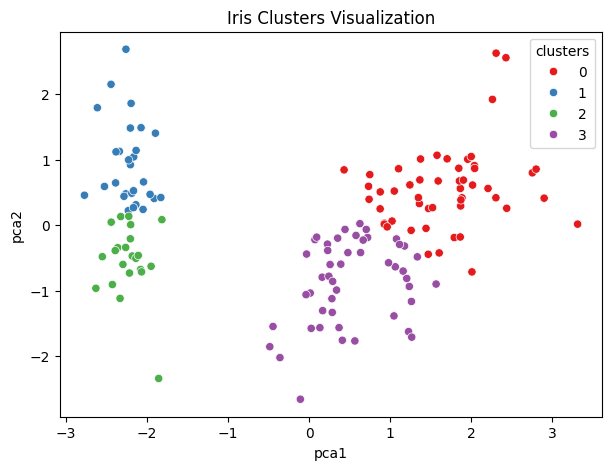

In [21]:
# visualizing clusters
#reduce dimensions to 2D
pca = PCA(n_components = 2)
# PCA reduces the 4-dimensional data into 2 new components so that we can visualize the data on a 2D graph. The 4 original features are mathematically combined to create PCA1 and PCA2.
x_pca = pca.fit_transform(x_scaled) # PCA learns the important directions from x_scaled and transforms the scaled data into 2 PCA components.
data['pca1']= x_pca[:, 0] # now there are 2 fetaures, we are adding that 2 features in the dataset, x_pca(:,0) - : means entire values from the row, and 0 means only 1st column
data['pca2'] = x_pca[:,1] # x_pca(:,1) - Take all rows and the second column of x_pca, which is PCA2.
plt.figure(figsize = (7,5))
sns.scatterplot(x = 'pca1', y ='pca2', hue = 'clusters', data = data, palette = 'Set1') # hue = clusters - meaning - each cluster gets a different color, so we can visually distinguish the groups created by K-Means.and colors must be taken from Set 1
plt.title("Iris Clusters Visualization")
plt.show()